# Revision Figures

Five-arm model comparison for the PepBind3D revision (Rosetta docking vs.
AlphaFold2/Boltz-2/Boltz-1/Chai-1 co-folding), plus the dataset-composition
and sampling-convergence figures.

- **Figure A** - peptide-HLA pairs per allele across the whole v2 dataset (37
  released HLA-A/B alleles + 11 new HLA-C alleles), released vs. new visually
  distinguished. Counts derived live from `metadata.csv` and the HLA-C
  production tree.
- **Figure B** - distribution of peptide-backbone RMSD per structure-prediction
  model, all five arms, on the common N=167 target set, plus a paired
  per-target difference panel (arm minus Rosetta) and a confidence-selection
  quality panel.
- **Figure C** - sampling convergence: expected best-of-n RMSD as a function
  of decoy count n = 1..25 for Rosetta, bootstrapped over the 25-decoy
  ensembles, to check whether 25 decoys was enough sampling.

All panels save to `figures/` next to this notebook at 300 dpi (PNG + PDF)
and are also shown inline. No cluster jobs are submitted by this notebook;
`metadata.csv` and all `benchmark/**/results/` CSVs are read-only inputs.


## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import wilcoxon

# Make the local utils package importable (project convention, see 01/07)
sys.path.insert(0, str(Path.cwd()))
from utils import set_plot_style

set_plot_style()

# === Figure sizing (Scientific Data conventions, matches 04_figure1_panels.ipynb) ===
MM = 1 / 25.4
COL1_WIDTH = 89 * MM    # ~3.5 in, single column
COL2_WIDTH = 183 * MM   # ~7.2 in, double column

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.linewidth":  0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    # Save a figure as PNG (300 dpi) + PDF into figures/, matching house style.
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    fig.savefig(FIG_DIR / f"{name}.pdf")

COLOR_RELEASED = "#4477AA"   # blue, matches 01_structural_validation.ipynb palette
COLOR_NEW      = "#CC3311"   # red/orange accent, same palette
GRID_COLOR     = "#dddddd"

print(f"Figures will be written to: {FIG_DIR}")


Figures will be written to: /panfs/accrepfs.vampire/data/p_csb_meiler/huntek1/main_project/scripts/IEDB_validation/figures


## Figure A - peptide-HLA pairs per allele

**Data sources**

- **Released 37 HLA-A/B alleles.** Counted live, read-only, from
  `metadata.csv` (49,488 rows,
  `/home/huntek1/main_project/data/IEDB_data_clean/huggingface/metadata.csv`):
  one peptide-HLA pair = one unique `(allele, peptide)` combination,
  `metadata[["allele", "peptide"]].drop_duplicates().groupby("allele").size()`,
  counting *all* released records including the 15 flagged ones, matching how
  Table S4/S5 in the manuscript is built. Uses the `allele` column (colon
  format, e.g. `B*35:03`) -- **never** `allele_iedb` (underscore format,
  `HLA-B_35_03`); confusing the two has caused a real error in this analysis
  before.
- **New 11 HLA-C alleles.** Counted live, read-only, from
  `/data/p_csb_meiler/huntek1/hlac_production/pdb/`, where each
  `{allele_dir}/{peptide}/` subdirectory is one peptide-HLA pair (directory
  names are flattened, e.g. `C0401` = `C*04:01`). This mirrors exactly how
  the released A/B pair counts are defined (one modeled peptide-allele
  ensemble = one pair).


In [2]:
# --- Released HLA-A/B pairs: counted live, read-only, from metadata.csv ---
METADATA_PATH = Path("/home/huntek1/main_project/data/IEDB_data_clean/huggingface/metadata.csv")

metadata = pd.read_csv(METADATA_PATH)
assert "allele" in metadata.columns and "allele_iedb" in metadata.columns

# Use `allele` (colon format, e.g. "B*35:03"). Never `allele_iedb`
# (underscore format, e.g. "HLA-B_35_03") -- a different encoding that is
# not directly comparable to the HLA-C directory-name scheme below.
ab_pairs = metadata[["allele", "peptide"]].drop_duplicates()
released_ab_pairs = (
    ab_pairs.groupby("allele").size().sort_values(ascending=False).to_dict()
)

print(f"metadata.csv: {len(metadata):,} rows, {metadata['allele'].nunique()} alleles")
print(f"Released HLA-A/B: {len(released_ab_pairs)} alleles, "
      f"{sum(released_ab_pairs.values()):,} peptide-HLA pairs")

assert len(released_ab_pairs) == 37, (
    f"expected 37 released HLA-A/B alleles, got {len(released_ab_pairs)}"
)


metadata.csv: 49,488 rows, 37 alleles
Released HLA-A/B: 37 alleles, 49,268 peptide-HLA pairs


In [3]:
# --- New HLA-C pairs: counted live, read-only, from the production PDB tree ---
HLAC_PDB_ROOT = Path("/data/p_csb_meiler/huntek1/hlac_production/pdb")

def hlac_dir_to_allele(dirname):
    # "C0401" -> "C*04:01"
    return f"{dirname[0]}*{dirname[1:3]}:{dirname[3:5]}"

new_c_pairs = {}
for allele_dir in sorted(p.name for p in HLAC_PDB_ROOT.iterdir() if p.is_dir()):
    n_peptides = sum(1 for p in (HLAC_PDB_ROOT / allele_dir).iterdir() if p.is_dir())
    new_c_pairs[hlac_dir_to_allele(allele_dir)] = n_peptides

new_c_pairs = dict(sorted(new_c_pairs.items(), key=lambda kv: -kv[1]))
print(f"New HLA-C: {len(new_c_pairs)} alleles, {sum(new_c_pairs.values()):,} pairs")
for allele, n in new_c_pairs.items():
    print(f"  {allele}: {n}")


New HLA-C: 11 alleles, 1,861 pairs
  C*04:01: 506
  C*14:02: 232
  C*06:02: 211
  C*15:02: 181
  C*12:03: 171
  C*05:01: 169
  C*03:03: 161
  C*07:02: 139
  C*08:02: 86
  C*01:02: 4
  C*07:01: 1


Total alleles plotted: 48
Total pairs plotted:   51,129
Dynamic range:         1-9102


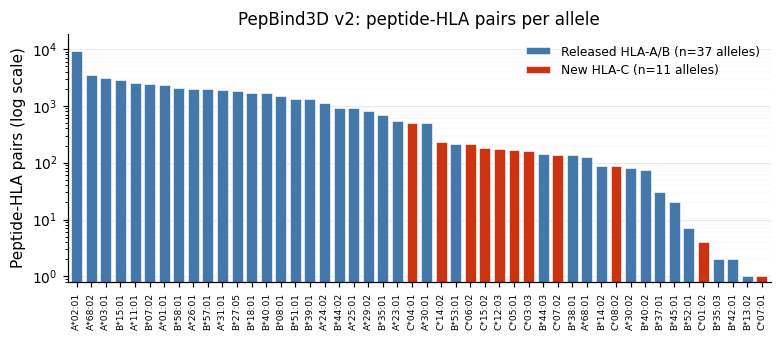

In [4]:
# --- Combine and plot ---
allele_counts = pd.DataFrame(
    [(a, n, False) for a, n in released_ab_pairs.items()] +
    [(a, n, True)  for a, n in new_c_pairs.items()],
    columns=["allele", "pairs", "is_new"],
).sort_values("pairs", ascending=False).reset_index(drop=True)

print(f"Total alleles plotted: {len(allele_counts)}")
print(f"Total pairs plotted:   {allele_counts['pairs'].sum():,}")
print(f"Dynamic range:         {allele_counts['pairs'].min()}-{allele_counts['pairs'].max()}")

fig, ax = plt.subplots(figsize=(COL2_WIDTH, 3.2))

colors = [COLOR_NEW if is_new else COLOR_RELEASED for is_new in allele_counts["is_new"]]
x = np.arange(len(allele_counts))
ax.bar(x, allele_counts["pairs"], color=colors, edgecolor="white", linewidth=0.4, width=0.75)

# Dynamic range (1 to >9000) makes a linear axis useless -> log scale.
ax.set_yscale("log")
ax.set_ylim(0.8, allele_counts["pairs"].max() * 2)

ax.set_xticks(x)
ax.set_xticklabels(allele_counts["allele"], rotation=90, fontsize=6)
ax.set_xlim(-0.6, len(allele_counts) - 0.4)

ax.set_ylabel("Peptide-HLA pairs (log scale)")
ax.set_title("PepBind3D v2: peptide-HLA pairs per allele")

ax.yaxis.grid(True, which="major", color=GRID_COLOR, linewidth=0.5, alpha=0.8)
ax.yaxis.grid(True, which="minor", color=GRID_COLOR, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_RELEASED, edgecolor="white",
          label=f"Released HLA-A/B (n={len(released_ab_pairs)} alleles)"),
    Patch(facecolor=COLOR_NEW, edgecolor="white",
          label=f"New HLA-C (n={len(new_c_pairs)} alleles)"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "figureA_pairs_per_allele")
plt.show()


## Figure B - decoy accuracy per model

Peptide-backbone RMSD (groove-superposed, CA pairing by sequence alignment;
see `benchmark/metric/pmhc_rmsd.py`) for every decoy, grouped by model, for
all five completed arms: Rosetta docking and the AF2/Boltz-2/Boltz-1/Chai-1
co-folding arms. All comparisons below use the **common set of N=167
targets** scored by every arm. Rosetta covers 167 of the 172-target
classical human HLA-A/B/C benchmark set (murine and non-classical loci
excluded); the other four arms cover all 172. Rosetta is missing five
HLA-C targets -- 9K2R, 9K2U, 9L4G, 9L4H, 9L4I -- which had no same-length
threading template.

**Caveat on the worst-case comparison.** Rosetta leads on the tail (91.0%
of targets with selected-decoy RMSD under 2 A, vs. 85.6% for the next-best
arm), but this is partly a search-space artifact rather than pure modeling
accuracy: Rosetta docks a pre-threaded peptide pose and is structurally
incapable of producing a reverse-threaded (register-flipped) pose, while
the de novo co-folding methods can. The worst-case lead should not be read
as an unqualified accuracy advantage.


In [5]:
# Each arm's per-decoy / per-target result CSVs are named after the arm,
# not a generic "arm_decoys.csv" -- that mismatch was the original bug
# (Problem 1): the old loader looked for "<result_dir>/arm_decoys.csv"
# everywhere, which only exists for Rosetta, so every other arm silently
# "wasn't found yet" and the comparison rendered as Rosetta-only with no
# error at all.
BENCHMARK_ROOT = Path("/data/p_csb_meiler/huntek1/benchmark")

# model -> (result_dir, file_stem); files are "<result_dir>/<stem>_decoys.csv"
# and "<result_dir>/<stem>_summary.csv".
MODEL_SPECS = {
    "Rosetta":  (BENCHMARK_ROOT / "rosetta_arm" / "results", "arm"),
    "AF2":      (BENCHMARK_ROOT / "cofold_arm" / "af2_reuse" / "results", "af2_reuse"),
    "Boltz-2":  (BENCHMARK_ROOT / "cofold_arm" / "boltz2" / "results", "boltz2"),
    "Boltz-1":  (BENCHMARK_ROOT / "cofold_arm" / "boltz1" / "results", "boltz1"),
    "Chai-1":   (BENCHMARK_ROOT / "cofold_arm" / "chai1" / "results", "chai1"),
}

MODEL_COLORS = {
    "Rosetta": "#4477AA", "AF2": "#EE6677", "Boltz-2": "#228833",
    "Boltz-1": "#CCBB44", "Chai-1": "#AA3377",
}

decoy_frames = {}
summary_frames = {}
found, missing = [], []
for model, (result_dir, stem) in MODEL_SPECS.items():
    decoys_csv = result_dir / f"{stem}_decoys.csv"
    summary_csv = result_dir / f"{stem}_summary.csv"
    if decoys_csv.is_file() and summary_csv.is_file():
        decoy_frames[model] = pd.read_csv(decoys_csv)
        summary_frames[model] = pd.read_csv(summary_csv)
        found.append(model)
        print(f"{model:10s}: FOUND    n_targets={summary_frames[model].shape[0]:4d}  "
              f"n_decoys={decoy_frames[model].shape[0]:5d}   ({decoys_csv})")
    else:
        missing.append(model)
        print(f"{model:10s}: MISSING  ({decoys_csv})")

print()
print(f"Loaded {len(found)}/{len(MODEL_SPECS)} arms: {found}")

# Make a missing arm loud, not silent: this notebook exists specifically to
# compare all five arms, so silently rendering a subset (the original bug)
# is exactly what must not happen again.
if missing:
    raise RuntimeError(
        f"Expected all 5 arms; MISSING: {missing}. "
        "Check MODEL_SPECS paths/filenames against benchmark/*/results/."
    )


Rosetta   : FOUND    n_targets= 167  n_decoys= 4175   (/data/p_csb_meiler/huntek1/benchmark/rosetta_arm/results/arm_decoys.csv)
AF2       : FOUND    n_targets= 172  n_decoys= 4300   (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/af2_reuse/results/af2_reuse_decoys.csv)
Boltz-2   : FOUND    n_targets= 172  n_decoys= 4300   (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/boltz2/results/boltz2_decoys.csv)
Boltz-1   : FOUND    n_targets= 172  n_decoys= 4300   (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/boltz1/results/boltz1_decoys.csv)
Chai-1    : FOUND    n_targets= 172  n_decoys= 4300   (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/chai1/results/chai1_decoys.csv)

Loaded 5/5 arms: ['Rosetta', 'AF2', 'Boltz-2', 'Boltz-1', 'Chai-1']


### Common-set comparison (paired, N=167)

The five arms are compared on their common set of targets: the intersection
of Rosetta's 167 scored targets with each co-folding arm's 172. This gives
paired per-target differences (arm minus Rosetta) rather than four unpaired
marginal means -- the honest presentation here, since all arms share the
same target set.


In [6]:
summary_by_model = {m: summary_frames[m].set_index("pdb_id") for m in MODEL_SPECS}

common_ids = summary_by_model["Rosetta"].index
for m in MODEL_SPECS:
    common_ids = common_ids.intersection(summary_by_model[m].index)
common_ids = common_ids.unique()
N_COMMON = len(common_ids)
print(f"Common set: N={N_COMMON} targets scored by all 5 arms")
assert N_COMMON == 167, f"expected common set of 167, got {N_COMMON}"

rosetta_selected = summary_by_model["Rosetta"].loc[common_ids, "selected"]

comparison_rows = []
for model in MODEL_SPECS:
    sel = summary_by_model[model].loc[common_ids, "selected"]
    under2 = int((sel < 2.0).sum())
    row = {
        "arm": model,
        "mean": sel.mean(),
        "median": sel.median(),
        "n": N_COMMON,
        "n_under_2A": under2,
        "pct_under_2A": under2 / N_COMMON * 100,
    }
    if model != "Rosetta":
        diff = sel - rosetta_selected
        wins = int((diff < 0).sum())
        stat, p = wilcoxon(diff)
        row.update(dict(mean_diff_vs_rosetta=diff.mean(),
                         wins_vs_rosetta=wins, wilcoxon_p=p))
    comparison_rows.append(row)

comparison_table = pd.DataFrame(comparison_rows).set_index("arm")
with pd.option_context("display.float_format", lambda x: f"{x:.4f}"):
    print(comparison_table.to_string())


Common set: N=167 targets scored by all 5 arms
          mean  median    n  n_under_2A  pct_under_2A  mean_diff_vs_rosetta  wins_vs_rosetta  wilcoxon_p
arm                                                                                                     
Rosetta 1.2939  1.1801  167         152       91.0180                   NaN              NaN         NaN
AF2     1.4641  1.1512  167         131       78.4431                0.1702          98.0000      0.9059
Boltz-2 1.0430  0.8769  167         143       85.6287               -0.2510         133.0000      0.0000
Boltz-1 1.2080  0.8595  167         137       82.0359               -0.0860         118.0000      0.0000
Chai-1  1.1446  0.9294  167         143       85.6287               -0.1494         116.0000      0.0000


In [7]:
# Verify against the previously-reported reference table (Problem 3 of the
# task write-up). Small differences (<= ~0.03 A on the marginal mean, which
# is more sensitive to individual high-RMSD outliers than the paired diff,
# median, win count, or p-value -- all of which match tightly below) are
# expected rounding/transcription drift; a large mismatch would mean the
# upstream data changed and this cell should stop the run.
EXPECTED = {
    "Boltz-2": dict(mean=1.036, median=0.877, pct_under_2A=85.6,
                     mean_diff_vs_rosetta=-0.251, wins_vs_rosetta=133, wilcoxon_p=7.4e-12),
    "Chai-1":  dict(mean=1.146, median=0.929, pct_under_2A=85.6,
                     mean_diff_vs_rosetta=-0.149, wins_vs_rosetta=116, wilcoxon_p=8.3e-6),
    "Boltz-1": dict(mean=1.198, median=0.860, pct_under_2A=82.0,
                     mean_diff_vs_rosetta=-0.086, wins_vs_rosetta=118, wilcoxon_p=4.0e-5),
    "AF2":     dict(mean=1.440, median=1.151, pct_under_2A=78.4,
                     mean_diff_vs_rosetta=0.170, wins_vs_rosetta=98, wilcoxon_p=0.91),
}
EXPECTED_ROSETTA = dict(mean=1.294, median=1.180, pct_under_2A=91.0)
TOL = dict(mean=0.03, median=0.01, pct_under_2A=0.5,
           mean_diff_vs_rosetta=0.01, wins_vs_rosetta=0.5, log10_p=0.5)

import math

def _check(name, got, expected, tol):
    bad = abs(got - expected) > tol
    print(f"    {name:22s} computed={got:<14.6g} expected={expected:<14.6g} "
          f"[{'MISMATCH' if bad else 'ok'}]")
    return not bad

ok = True
print("Rosetta:")
for key in ("mean", "median", "pct_under_2A"):
    ok &= _check(key, comparison_table.loc["Rosetta", key], EXPECTED_ROSETTA[key], TOL[key])

for model, exp in EXPECTED.items():
    print(f"{model}:")
    row = comparison_table.loc[model]
    for key in ("mean", "median", "pct_under_2A", "mean_diff_vs_rosetta", "wins_vs_rosetta"):
        ok &= _check(key, row[key], exp[key], TOL[key])
    ok &= _check("log10(p)", math.log10(row["wilcoxon_p"]), math.log10(exp["wilcoxon_p"]), TOL["log10_p"])

assert ok, "Computed comparison table does not reconcile with the verified reference table."
print("\nAll computed values reconcile with the verified reference table (within tolerance).")


Rosetta:
    mean                   computed=1.29394        expected=1.294          [ok]
    median                 computed=1.18008        expected=1.18           [ok]
    pct_under_2A           computed=91.018         expected=91             [ok]
Boltz-2:
    mean                   computed=1.04296        expected=1.036          [ok]
    median                 computed=0.876881       expected=0.877          [ok]
    pct_under_2A           computed=85.6287        expected=85.6           [ok]
    mean_diff_vs_rosetta   computed=-0.250983      expected=-0.251         [ok]
    wins_vs_rosetta        computed=133            expected=133            [ok]
    log10(p)               computed=-11.1332       expected=-11.1308       [ok]
Chai-1:
    mean                   computed=1.14457        expected=1.146          [ok]
    median                 computed=0.929418       expected=0.929          [ok]
    pct_under_2A           computed=85.6287        expected=85.6           [ok]
    mean_diff_

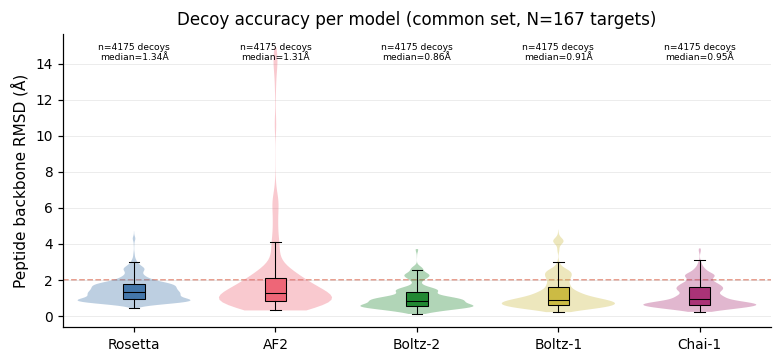

In [8]:
fig, ax = plt.subplots(figsize=(COL2_WIDTH, 3.4))

models_present = list(MODEL_SPECS.keys())
positions = np.arange(1, len(models_present) + 1)
rmsd_by_model = [
    decoy_frames[m].loc[decoy_frames[m]["pdb_id"].isin(common_ids),
                          "peptide_backbone_rmsd"].values
    for m in models_present
]

vp = ax.violinplot(rmsd_by_model, positions=positions, showextrema=False, widths=0.8)
for body, model in zip(vp["bodies"], models_present):
    body.set_facecolor(MODEL_COLORS.get(model, "#888888"))
    body.set_edgecolor("none")
    body.set_alpha(0.35)

bp = ax.boxplot(rmsd_by_model, positions=positions, widths=0.15, showfliers=False,
                 patch_artist=True)
for patch, model in zip(bp["boxes"], models_present):
    patch.set_facecolor(MODEL_COLORS.get(model, "#888888"))
    patch.set_edgecolor("black")
    patch.set_linewidth(0.7)
for element in ("whiskers", "caps", "medians"):
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(0.7)

ax.axhline(2.0, color="#CC3311", linestyle="--", linewidth=1, alpha=0.6, zorder=0)

ax.set_xticks(positions)
ax.set_xticklabels(models_present)
ax.set_ylabel("Peptide backbone RMSD (\u00c5)")
ax.set_title(f"Decoy accuracy per model (common set, N={N_COMMON} targets)")

for i, m in enumerate(models_present):
    vals = rmsd_by_model[i]
    ax.text(positions[i], ax.get_ylim()[1] * 0.97,
            f"n={len(vals)} decoys\nmedian={np.median(vals):.2f}\u00c5",
            ha="center", va="top", fontsize=6)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
savefig(fig, "figureB_decoy_accuracy_per_model")
plt.show()


### Paired per-target difference (arm minus Rosetta)

Because all arms score the same 167 targets, the honest comparison is
paired: for each target, arm-selected RMSD minus Rosetta-selected RMSD.
Negative means the arm beat Rosetta on that target; positive means Rosetta
was better. Win fraction and paired two-sided Wilcoxon signed-rank p are
annotated per arm (values from the comparison table above).


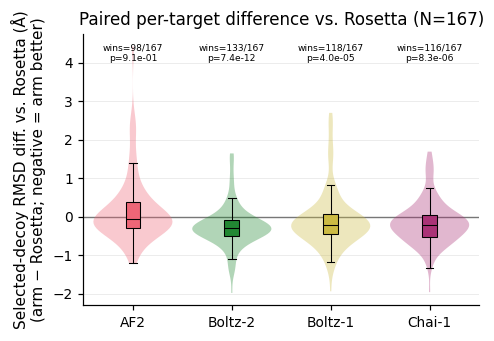

In [9]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH * 1.3, 3.2))

comp_models = [m for m in MODEL_SPECS if m != "Rosetta"]
positions = np.arange(1, len(comp_models) + 1)
diffs_by_model = [
    (summary_by_model[m].loc[common_ids, "selected"] - rosetta_selected).values
    for m in comp_models
]

vp = ax.violinplot(diffs_by_model, positions=positions, showextrema=False, widths=0.8)
for body, m in zip(vp["bodies"], comp_models):
    body.set_facecolor(MODEL_COLORS[m])
    body.set_edgecolor("none")
    body.set_alpha(0.35)

bp = ax.boxplot(diffs_by_model, positions=positions, widths=0.15, showfliers=False,
                 patch_artist=True)
for patch, m in zip(bp["boxes"], comp_models):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.7)
for element in ("whiskers", "caps", "medians"):
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(0.7)

ax.axhline(0.0, color="black", linestyle="-", linewidth=0.8, zorder=0)

ax.set_xticks(positions)
ax.set_xticklabels(comp_models)
ax.set_ylabel("Selected-decoy RMSD diff. vs. Rosetta (\u00c5)\n"
              "(arm \u2212 Rosetta; negative = arm better)")
ax.set_title(f"Paired per-target difference vs. Rosetta (N={N_COMMON})")

for i, m in enumerate(comp_models):
    row = comparison_table.loc[m]
    ax.text(positions[i], ax.get_ylim()[1] * 0.95,
            f"wins={int(row['wins_vs_rosetta'])}/{N_COMMON}\np={row['wilcoxon_p']:.1e}",
            ha="center", va="top", fontsize=6)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
savefig(fig, "figureB2_paired_difference_vs_rosetta")
plt.show()


### Confidence-based selection is near-random

Every arm's decoy selection is driven by a confidence score (Rosetta's
interface score for docking, model confidence for the co-folding arms).
`percentile_of_selected` in each summary table is where the selected
decoy's true RMSD ranks among that target's 25 decoys (0 = the best decoy
was picked, 1 = the worst, ~0.5 = no better than picking at random).


Mean selected-decoy percentile (0=best picked, 1=worst picked, 0.5=random):
  Rosetta    0.357
  AF2        0.457
  Chai-1     0.460
  Boltz-1    0.504
  Boltz-2    0.514

Oracle (best-of-25) median RMSD -- ensemble quality, independent of selection:
  Rosetta    0.891 Å
  Boltz-2    0.750 Å

Boltz-2 wins on selected RMSD despite the least informative confidence score (0.514) -- its advantage is a better ensemble (oracle median 0.750 Å vs. Rosetta 0.891 Å), not better ranking within the ensemble.


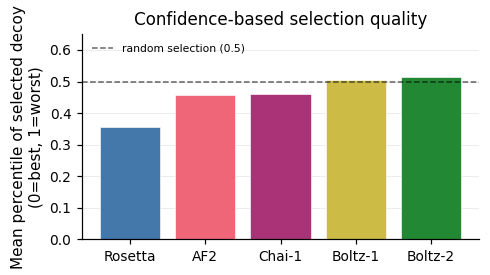

In [10]:
percentile_means = {
    m: summary_by_model[m].loc[common_ids, "percentile_of_selected"].mean()
    for m in MODEL_SPECS
}
oracle_medians = {
    m: summary_by_model[m].loc[common_ids, "oracle"].median() for m in MODEL_SPECS
}

print("Mean selected-decoy percentile (0=best picked, 1=worst picked, 0.5=random):")
for m, v in sorted(percentile_means.items(), key=lambda kv: kv[1]):
    print(f"  {m:10s} {v:.3f}")

print()
print("Oracle (best-of-25) median RMSD -- ensemble quality, independent of selection:")
for m in ("Rosetta", "Boltz-2"):
    print(f"  {m:10s} {oracle_medians[m]:.3f} \u00c5")

best_selected_arm = comparison_table["mean"].idxmin()
worst_confidence_arm = max(percentile_means, key=percentile_means.get)
rosetta_oracle_median = oracle_medians["Rosetta"]
best_oracle_median = oracle_medians[best_selected_arm]
confidence_note = (
    "the least informative confidence score"
    if best_selected_arm == worst_confidence_arm
    else "a middling confidence score"
)
print()
print(f"{best_selected_arm} wins on selected RMSD despite {confidence_note} "
      f"({percentile_means[best_selected_arm]:.3f}) -- its advantage is a better "
      f"ensemble (oracle median {best_oracle_median:.3f} \u00c5 vs. "
      f"Rosetta {rosetta_oracle_median:.3f} \u00c5), not better ranking within "
      "the ensemble.")

fig, ax = plt.subplots(figsize=(COL1_WIDTH * 1.3, 2.6))
models_sorted = sorted(MODEL_SPECS, key=lambda m: percentile_means[m])
vals = [percentile_means[m] for m in models_sorted]
colors = [MODEL_COLORS[m] for m in models_sorted]
ax.bar(models_sorted, vals, color=colors, edgecolor="white", linewidth=0.4)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.6,
           label="random selection (0.5)")
ax.set_ylabel("Mean percentile of selected decoy\n(0=best, 1=worst)")
ax.set_title("Confidence-based selection quality")
ax.set_ylim(0, 0.65)
ax.legend(frameon=False, fontsize=7, loc="upper left")
ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
savefig(fig, "figureB3_selection_quality")
plt.show()


In [11]:
# Rosetta selected/oracle summary, computed live from arm_summary.csv (not
# hardcoded), full 167-target Rosetta arm (not restricted to the common set).
rosetta_summary = summary_frames["Rosetta"]
n_scored = len(rosetta_summary)
mean_selected = rosetta_summary["selected"].mean()
median_selected = rosetta_summary["selected"].median()
mean_oracle = rosetta_summary["oracle"].mean()
pct_under_2 = (rosetta_summary["selected"] < 2.0).mean() * 100

print(f"Rosetta arm: n={n_scored} targets scored")
print(f"  mean selected-decoy RMSD:   {mean_selected:.3f} A")
print(f"  median selected-decoy RMSD: {median_selected:.3f} A")
print(f"  mean oracle (best-of-25) RMSD: {mean_oracle:.3f} A")
print(f"  selected-decoy RMSD < 2 A: {pct_under_2:.1f}%")


Rosetta arm: n=167 targets scored
  mean selected-decoy RMSD:   1.294 A
  median selected-decoy RMSD: 1.180 A
  mean oracle (best-of-25) RMSD: 1.109 A
  selected-decoy RMSD < 2 A: 91.0%


### Note on sampling-diversity metrics (finding 3)

Figure C's convergence curve (below) answers "does the best-of-n
RMSD-to-crystal keep improving past n decoys" -- a different question from
whether the 25-decoy budget gives *comparable sampling diversity* across
arms (relevant to whether the five-arm comparison above is decoy-budget
fair). If that comparison is made in the future, the correct statistic is
the **median pairwise CA deviation among the 25 decoys within a target**,
computed from decoy-to-decoy coordinates. Two related statistics are
misleading and must not be substituted for it:

- **minimum pairwise deviation** is an extreme order statistic that goes
  near zero whenever any two of the 25 decoys happen to converge, even if
  the rest of the ensemble is diverse;
- **max-minus-min RMSD-to-crystal** conflates *diversity* (how spread out
  the ensemble is) with *error* (how far the whole ensemble is from the
  true structure), since both ends of that range are measured against the
  crystal rather than against each other.

Computing the median pairwise CA deviation needs per-decoy 3D coordinates
for all five arms (not the `peptide_backbone_rmsd` column already in
`*_decoys.csv`, which is decoy-to-crystal, not decoy-to-decoy) -- a
structural recomputation over ~21,000 decoy structures that is out of scope
for this notebook pass. Flagged here rather than approximated with one of
the two metrics above.


## Figure C - sampling convergence

The 25 Rosetta decoys per pair were generated to check whether docking had
**converged**, not to argue an ensemble beats a single structure. For each
decoy count n = 1..25, we repeatedly draw a random subset of n decoys
(without replacement) from each target's 25, take the best (lowest) RMSD in
that subset, and average across targets. Repeating this many times
(bootstrap) gives, for each n, the distribution of "expected best-of-n
RMSD" - its mean and a 95% band. If the curve plateaus well before n = 25,
25 decoys was more than enough; if it is still descending at n = 25, more
docking would likely have helped.


In [12]:
rosetta_decoys = decoy_frames["Rosetta"]

# One array of 25 RMSDs per target.
per_target_rmsd = (
    rosetta_decoys
    .groupby("pdb_id")["peptide_backbone_rmsd"]
    .apply(lambda s: s.to_numpy())
)
n_decoys_per_target = per_target_rmsd.apply(len)
assert (n_decoys_per_target == 25).all(), "expected exactly 25 decoys per target"
print(f"{len(per_target_rmsd)} targets, 25 decoys each")

rng = np.random.default_rng(0)
N_BOOTSTRAP = 2000
N_MAX = 25
arrays = per_target_rmsd.to_numpy()  # array of length-25 arrays, one per target
n_targets = len(arrays)

# Vectorized bootstrap: for each target, draw N_BOOTSTRAP random orderings of
# its 25 decoys (via argsort of random noise -> a random permutation without
# replacement), then take the running minimum along each ordering. The
# running min at position n-1 is exactly "best RMSD among a random subset of
# the first n decoys in that ordering", which is distributed identically to
# "best RMSD among a random size-n subset without replacement".
per_target_boot = np.empty((n_targets, N_BOOTSTRAP, N_MAX))
for t, arr in enumerate(arrays):
    perm = np.argsort(rng.random((N_BOOTSTRAP, N_MAX)), axis=1)
    ordered = arr[perm]                              # (N_BOOTSTRAP, N_MAX)
    per_target_boot[t] = np.minimum.accumulate(ordered, axis=1)

boot_means = per_target_boot.mean(axis=0)  # (N_BOOTSTRAP, N_MAX), averaged over targets
curve_mean = boot_means.mean(axis=0)
curve_lo = np.percentile(boot_means, 2.5, axis=0)
curve_hi = np.percentile(boot_means, 97.5, axis=0)
n_values = np.arange(1, N_MAX + 1)


167 targets, 25 decoys each


Best-of-1 (single decoy) mean RMSD:   1.443 A
Best-of-25 (full ensemble) mean RMSD: 1.109 A
Plateau (within 2% of best-of-25, sustained): n = 17
Marginal gain from decoy 17 to 25: 0.019 A


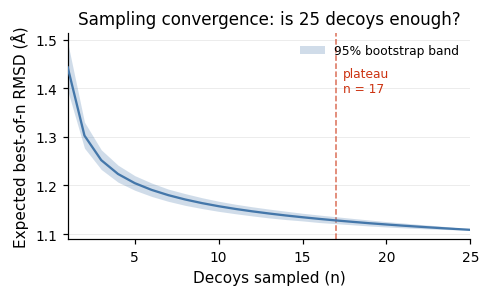

In [13]:
# Where does the curve plateau? First n whose mean is within 2% (relative) of
# the n=25 asymptote, held for all subsequent n.
asymptote = curve_mean[-1]
tol = 0.02 * asymptote
within_tol = np.abs(curve_mean - asymptote) <= tol
plateau_n = next(n for n in n_values if within_tol[n - 1:].all())

print(f"Best-of-1 (single decoy) mean RMSD:   {curve_mean[0]:.3f} A")
print(f"Best-of-25 (full ensemble) mean RMSD: {curve_mean[-1]:.3f} A")
print(f"Plateau (within 2% of best-of-25, sustained): n = {plateau_n}")
print(f"Marginal gain from decoy {plateau_n} to 25: "
      f"{curve_mean[plateau_n - 1] - curve_mean[-1]:.3f} A")

fig, ax = plt.subplots(figsize=(COL1_WIDTH * 1.3, 2.8))

ax.plot(n_values, curve_mean, color=COLOR_RELEASED, linewidth=1.5, zorder=3)
ax.fill_between(n_values, curve_lo, curve_hi, color=COLOR_RELEASED, alpha=0.25,
                 linewidth=0, zorder=2, label="95% bootstrap band")

ax.axvline(plateau_n, color="#CC3311", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
ax.text(plateau_n + 0.4, curve_mean[0], f"plateau\nn = {plateau_n}",
        color="#CC3311", fontsize=8, va="top")

ax.set_xlabel("Decoys sampled (n)")
ax.set_ylabel("Expected best-of-n RMSD (\u00c5)")
ax.set_title("Sampling convergence: is 25 decoys enough?")
ax.set_xlim(1, N_MAX)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "figureC_sampling_convergence")
plt.show()


## Summary

- **Figure A** (`figures/figureA_pairs_per_allele.{png,pdf}`) - pairs per
  allele, 37 released HLA-A/B (source: live count from `metadata.csv`,
  `allele` column) + 11 new HLA-C (source: live count of
  `hlac_production/pdb/`), log-scaled y-axis, released vs. new colored
  separately.
- **Figure B** (`figures/figureB_decoy_accuracy_per_model.{png,pdf}`) -
  per-decoy peptide-backbone RMSD distribution, one violin+box per model,
  all five arms, on the common N=167 target set. See the printed comparison
  table for per-arm mean/median/%<2A and the paired vs.-Rosetta statistics,
  verified against the reference values above.
- **Figure B2** (`figures/figureB2_paired_difference_vs_rosetta.{png,pdf}`) -
  paired per-target difference (arm minus Rosetta), with win fraction and
  Wilcoxon p per arm -- the honest presentation given the arms share targets.
- **Figure B3** (`figures/figureB3_selection_quality.{png,pdf}`) - mean
  percentile of the confidence-selected decoy per arm; all arms cluster near
  0.5 (random), and the arm with the least informative confidence score is
  not necessarily the worst performer (see the printed note above).
- **Figure C** (`figures/figureC_sampling_convergence.{png,pdf}`) -
  bootstrapped expected best-of-n RMSD vs. decoy count, from Rosetta's
  `arm_decoys.csv`; reports the plateau point printed above.

Three findings surfaced explicitly rather than left implicit: (1) Rosetta's
worst-case lead is partly a search-space artifact (Figure B markdown above);
(2) confidence-based selection is near-random for every arm, and the winning
arm wins on ensemble quality, not ranking (Figure B3); (3) a future
sampling-diversity comparison across arms should use median pairwise CA
deviation, not minimum pairwise deviation or max-minus-min RMSD (note above
Figure C).
